# Arbitrary circumburst media in VegasAfterglow

This notebook explores how the external density profile changes a standard GRB afterglow in `VegasAfterglow`. It uses the **standard analytic synchrotron model** throughout; arbitrary electron distributions are intentionally kept in a separate notebook.

The baseline comparison is between a constant-density ISM, a smooth stellar wind, and a wind containing radial overdensities. The custom profile is evaluated through `Medium(rho=..., isotropic=True)`, where `rho(phi, theta, r)` returns mass density in g cm$^{-3}$.

The radial "clumps" used below are spherical shell-like overdensities, chosen because they isolate density structure while retaining the fast isotropic-medium path. A truly localized angular clump is shown as an optional extension at the end.


## 1. Setup

Edit the constants in this section for routine experiments. The default parameters are representative of a long-GRB afterglow and are held fixed so that differences between curves come only from the external medium.


In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np

from VegasAfterglow import (
    ISM,
    Medium,
    Model,
    Observer,
    Radiation,
    TophatJet,
    Wind,
)

%matplotlib inline

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.18,
    "lines.linewidth": 1.8,
    "legend.frameon": False,
})

FIGURE_DIR = Path("out/arbitrary_medium")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DPI = 220
FIGSIZE, WIDE_FIGSIZE, TRIPLE_FIGSIZE = (8, 5), (12, 5), (16, 5)

# Baseline long-GRB afterglow
E_ISO = 1e53
GAMMA0 = 300.0
THETA_C = 0.1
LUMI_DIST = 1e28
REDSHIFT = 0.1
THETA_OBS = 0.0

P = 2.3
EPS_E = 0.1
EPS_B = 1e-3
XI_E = 1.0
RESOLUTIONS = (0.1, 0.25, 10)

# Medium normalizations
M_P = 1.67262192369e-24  # g
N_ISM = 1.0             # cm^-3
A_STAR = 0.1
WIND_A = 5e11 * A_STAR  # rho = A / r^2, A in g cm^-1

# Observer grids
BANDS = {
    "Radio (10 GHz)": 1e10,
    "Optical (r band)": 4.8e14,
    "X-ray (1 keV)": 2.418e17,
}
LC_TIMES = np.logspace(1, 8, 260)
SPECTRUM_TIMES = np.array([1e2, 1e4, 1e6])
NU = np.logspace(7, 22, 320)
RADIUS = np.logspace(15, 20, 500)

FNU_LABEL = r"$F_\nu$ [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]"


In [2]:
def make_model(medium, *, ssa=True):
    return Model(
        jet=TophatJet(theta_c=THETA_C, E_iso=E_ISO, Gamma0=GAMMA0),
        medium=medium,
        observer=Observer(
            lumi_dist=LUMI_DIST,
            z=REDSHIFT,
            theta_obs=THETA_OBS,
        ),
        fwd_rad=Radiation(
            eps_e=EPS_E,
            eps_B=EPS_B,
            p=P,
            xi_e=XI_E,
            ssa=ssa,
        ),
        resolutions=RESOLUTIONS,
    )


def positive_xy(x, y):
    x, y = np.asarray(x), np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    return x[mask], y[mask]


def plot_positive(ax, x, y, *args, **kwargs):
    return ax.loglog(*positive_xy(x, y), *args, **kwargs)


def show_figure(fig, filename):
    rect = [0, 0, 1, 0.95] if fig._suptitle is not None else None
    fig.tight_layout(rect=rect)
    fig.savefig(FIGURE_DIR / f"{filename}.png", dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def spectrum_axes(ax, title=None):
    ax.set(
        xlabel="Observer frequency [Hz]",
        ylabel=FNU_LABEL,
        title=title,
    )


## 2. Define the media

`ISM` and `Wind` are built-in media. The custom clumpy wind uses the same smooth-wind normalization,

$$
\rho_{\rm w}(r)=\frac{5\times10^{11}A_*}{r^2}\;{\rm g\,cm^{-3}},
$$

multiplied by Gaussian overdensities in $\ln r$. The parameter `CLUMP_EXCESS` is the **fractional excess** above the smooth wind, so an excess of 9 gives a peak density of $10\rho_{\rm w}$.


In [3]:
# Radial overdensities in the wind
CLUMP_RADII = (3e16, 1e17, 4e17)       # cm
CLUMP_EXCESS = (9.0, 4.0, 9.0)         # peak rho/rho_w = 1 + excess
CLUMP_WIDTHS = (0.12, 0.10, 0.12)       # Gaussian sigma in ln(r)


def smooth_wind_density(phi, theta, r):
    r = max(float(r), 1.0)
    return WIND_A / r**2


def clumpy_wind_density(phi, theta, r):
    r = max(float(r), 1.0)
    enhancement = 1.0

    for r0, excess, width in zip(CLUMP_RADII, CLUMP_EXCESS, CLUMP_WIDTHS):
        x = math.log(r / r0) / width
        enhancement += excess * math.exp(-0.5 * x**2)

    return (WIND_A / r**2) * enhancement


ism = ISM(n_ism=N_ISM)
wind = Wind(A_star=A_STAR)
custom_wind = Medium(rho=smooth_wind_density, isotropic=True)
clumpy_wind = Medium(rho=clumpy_wind_density, isotropic=True)

MEDIA = {
    "ISM": ism,
    "Wind": wind,
    "Clumpy wind": clumpy_wind,
}


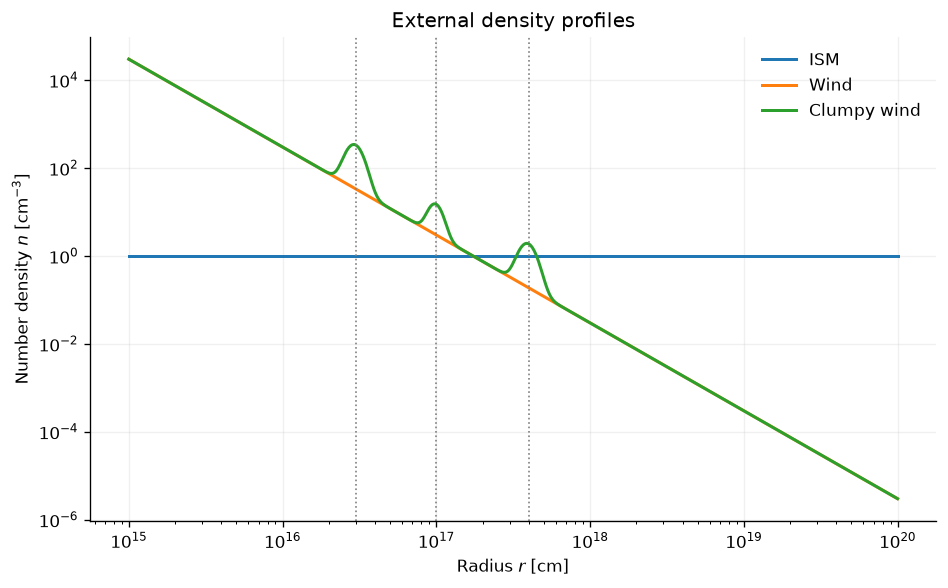

In [4]:
# Visualize the density profiles as number density n = rho / m_p.
n_ism_profile = np.full_like(RADIUS, N_ISM)
n_wind_profile = WIND_A / RADIUS**2 / M_P
n_clumpy_profile = np.array([
    clumpy_wind_density(0.0, 0.0, r) / M_P
    for r in RADIUS
])

fig, ax = plt.subplots(figsize=FIGSIZE)
plot_positive(ax, RADIUS, n_ism_profile, label="ISM")
plot_positive(ax, RADIUS, n_wind_profile, label="Wind")
plot_positive(ax, RADIUS, n_clumpy_profile, label="Clumpy wind")

for r0 in CLUMP_RADII:
    ax.axvline(r0, color="0.5", ls=":", lw=1)

ax.set(
    xlabel=r"Radius $r$ [cm]",
    ylabel=r"Number density $n$ [cm$^{-3}$]",
    title="External density profiles",
)
ax.legend()
show_figure(fig, "01_density_profiles")


### 2.1 Custom-medium sanity check

Before adding structure, compare the built-in `Wind` model with the equivalent custom callback. This isolates the `Medium` interface itself. The curves should agree closely; a large discrepancy would indicate a normalization or unit mismatch in the custom density function.


Maximum custom/built-in wind relative difference: 1.784e-06


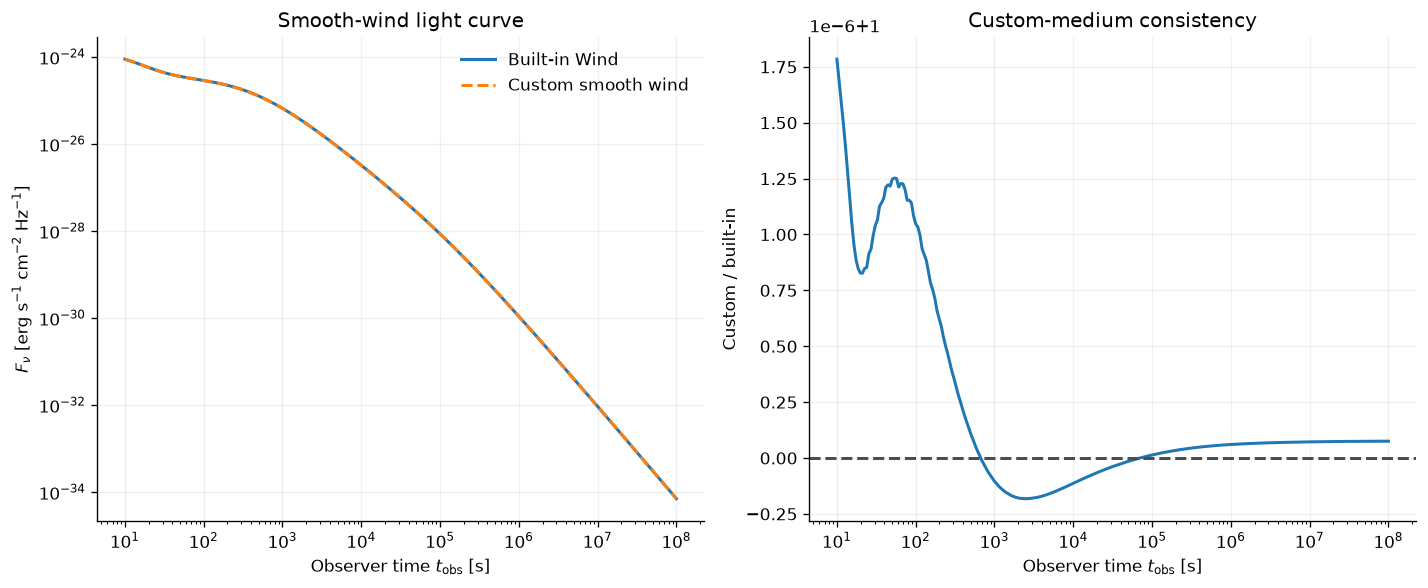

In [5]:
wind_builtin_model = make_model(wind)
wind_custom_model = make_model(custom_wind)

nu_check = BANDS["Optical (r band)"]
builtin_flux = wind_builtin_model.flux_density_grid(LC_TIMES, [nu_check]).total[0]
custom_flux = wind_custom_model.flux_density_grid(LC_TIMES, [nu_check]).total[0]

valid = np.isfinite(builtin_flux) & np.isfinite(custom_flux) & (builtin_flux > 0)
relative_difference = np.abs(custom_flux[valid] / builtin_flux[valid] - 1)
print(f"Maximum custom/built-in wind relative difference: {relative_difference.max():.3e}")

fig, axes = plt.subplots(1, 2, figsize=WIDE_FIGSIZE)
plot_positive(axes[0], LC_TIMES, builtin_flux, label="Built-in Wind")
plot_positive(axes[0], LC_TIMES, custom_flux, ls="--", label="Custom smooth wind")
axes[0].set(
    xlabel=r"Observer time $t_{\rm obs}$ [s]",
    ylabel=FNU_LABEL,
    title="Smooth-wind light curve",
)
axes[0].legend()

axes[1].semilogx(
    LC_TIMES[valid],
    custom_flux[valid] / builtin_flux[valid],
)
axes[1].axhline(1, color="0.3", ls="--")
axes[1].set(
    xlabel=r"Observer time $t_{\rm obs}$ [s]",
    ylabel="Custom / built-in",
    title="Custom-medium consistency",
)
show_figure(fig, "02_custom_wind_check")


## 3. Multi-band light curves

The same jet and microphysics are propagated through the three external media. Differences therefore reflect the density profile and its dynamical consequences. Density structures are not expected to map one-to-one into sharp flux spikes: blast-wave dynamics and equal-arrival-time integration smooth the response.


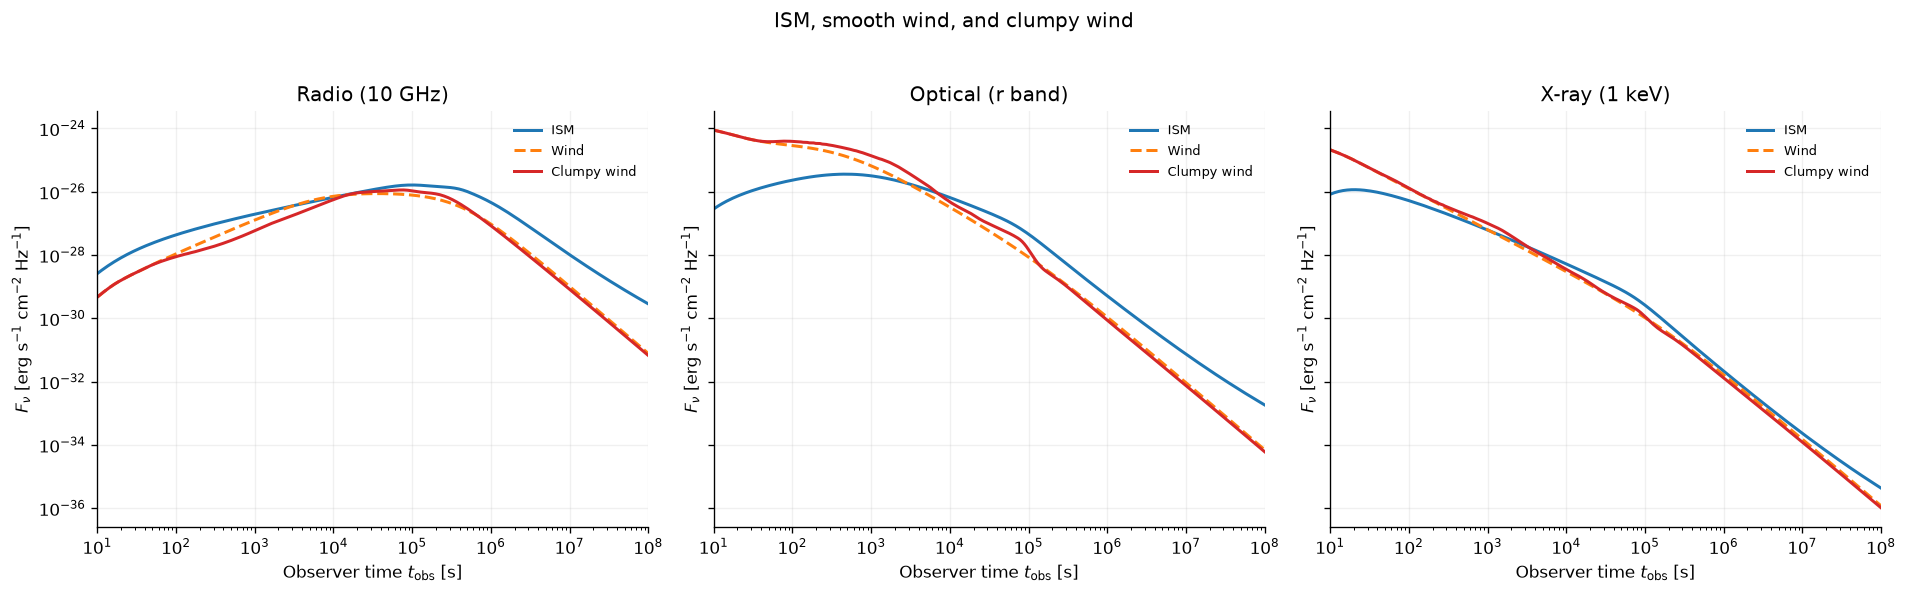

In [6]:
models = {name: make_model(medium) for name, medium in MEDIA.items()}
band_freqs = np.array(list(BANDS.values()))

light_curves = {
    name: model.flux_density_grid(LC_TIMES, band_freqs).total
    for name, model in models.items()
}

fig, axes = plt.subplots(1, 3, figsize=TRIPLE_FIGSIZE, sharey=True)
styles = {
    "ISM": dict(color="C0", ls="-"),
    "Wind": dict(color="C1", ls="--"),
    "Clumpy wind": dict(color="C3", ls="-"),
}

for j, (ax, band) in enumerate(zip(axes, BANDS)):
    for name in MEDIA:
        plot_positive(
            ax,
            LC_TIMES,
            light_curves[name][j],
            label=name,
            **styles[name],
        )

    ax.set(
        xlabel=r"Observer time $t_{\rm obs}$ [s]",
        ylabel=FNU_LABEL,
        title=band,
        xlim=(LC_TIMES[0], LC_TIMES[-1]),
    )
    ax.legend(fontsize=8)

fig.suptitle("ISM, smooth wind, and clumpy wind")
show_figure(fig, "03_light_curves")


### 3.1 Isolate the clump imprint

Dividing the clumpy-wind light curve by the smooth-wind result removes most of the secular wind evolution and makes the response to the overdensities easier to see. Deviations from unity need not occur exactly when the shock radius equals a clump radius because the observed flux integrates over the equal-arrival-time surface.


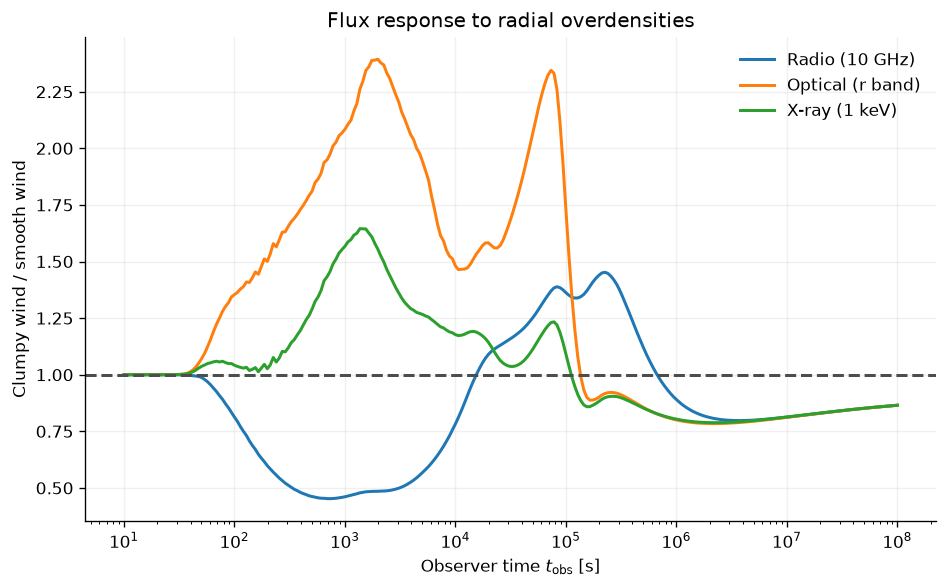

In [7]:
fig, ax = plt.subplots(figsize=FIGSIZE)

for j, band in enumerate(BANDS):
    smooth = light_curves["Wind"][j]
    clumpy = light_curves["Clumpy wind"][j]
    valid = np.isfinite(smooth) & np.isfinite(clumpy) & (smooth > 0)

    ax.semilogx(
        LC_TIMES[valid],
        clumpy[valid] / smooth[valid],
        label=band,
    )

ax.axhline(1, color="0.3", ls="--")
ax.set(
    xlabel=r"Observer time $t_{\rm obs}$ [s]",
    ylabel="Clumpy wind / smooth wind",
    title="Flux response to radial overdensities",
)
ax.legend()
show_figure(fig, "04_clump_flux_ratio")


## 4. Broadband spectra

These spectra show how the same environmental differences appear at fixed observer times. The standard synchrotron prescription is used in every panel, including its analytic break evolution and self-absorption treatment.


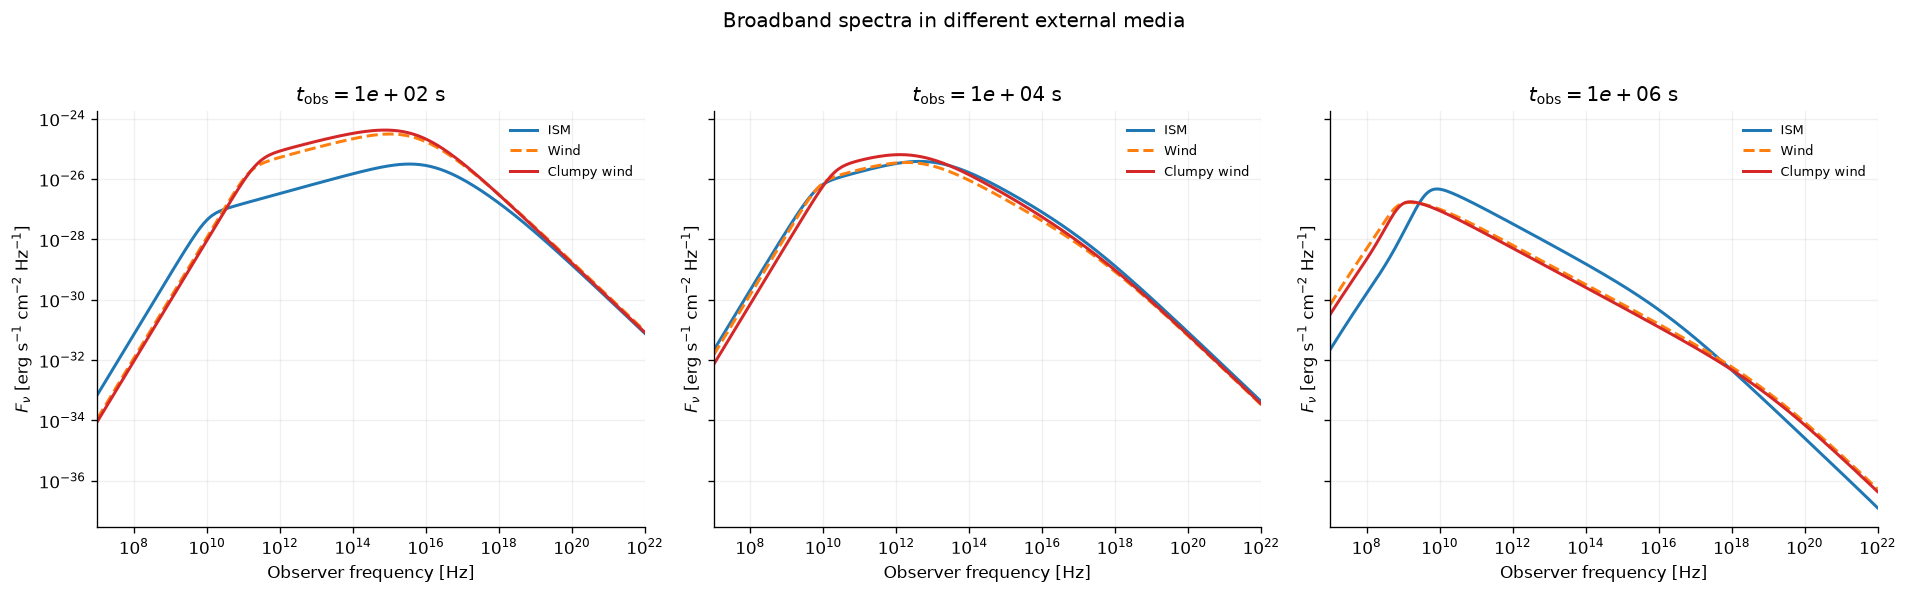

In [8]:
spectra = {
    name: model.flux_density_grid(SPECTRUM_TIMES, NU).total
    for name, model in models.items()
}

fig, axes = plt.subplots(1, 3, figsize=TRIPLE_FIGSIZE, sharey=True)

for i, (ax, t_obs) in enumerate(zip(axes, SPECTRUM_TIMES)):
    for name in MEDIA:
        plot_positive(
            ax,
            NU,
            spectra[name][:, i],
            label=name,
            **styles[name],
        )

    spectrum_axes(ax, rf"$t_{{\rm obs}}={t_obs:.0e}$ s")
    ax.set_xlim(NU[0], NU[-1])
    ax.legend(fontsize=8)

fig.suptitle("Broadband spectra in different external media")
show_figure(fig, "05_spectra")


## 5. Dynamical response to the clumps

The radial density enhancements alter the blast-wave dynamics as well as the instantaneous emissivity. The figure below follows the on-axis forward-shock cell in a smooth wind and in the clumpy wind. The first panel evaluates the external density at the shock radius; the second shows the corresponding Lorentz-factor evolution.


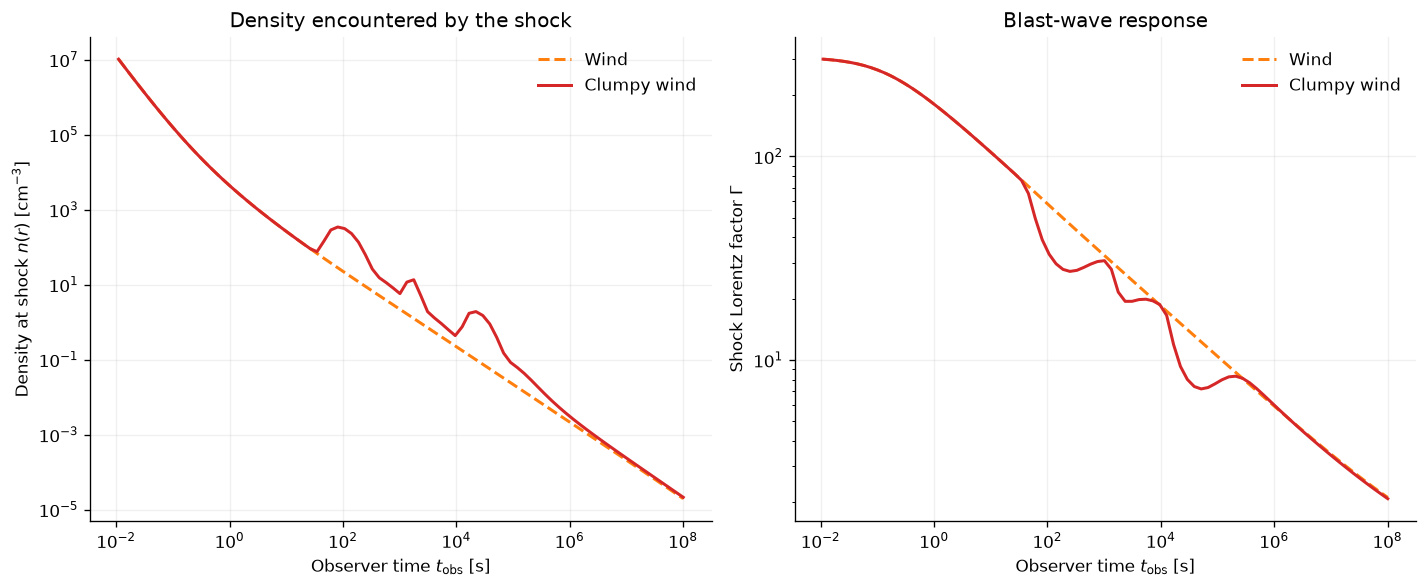

In [9]:
wind_details = models["Wind"].details(LC_TIMES[0], LC_TIMES[-1])
clumpy_details = models["Clumpy wind"].details(LC_TIMES[0], LC_TIMES[-1])

fig, axes = plt.subplots(1, 2, figsize=WIDE_FIGSIZE)

for name, details, density_function, style in (
    ("Wind", wind_details, smooth_wind_density, styles["Wind"]),
    ("Clumpy wind", clumpy_details, clumpy_wind_density, styles["Clumpy wind"]),
):
    t_obs = np.asarray(details.fwd.t_obs[0, 0, :])
    radius = np.asarray(details.fwd.r[0, 0, :])
    gamma = np.asarray(details.fwd.Gamma[0, 0, :])
    n_external = np.array([
        density_function(0.0, 0.0, r) / M_P
        for r in radius
    ])

    plot_positive(axes[0], t_obs, n_external, label=name, **style)
    plot_positive(axes[1], t_obs, gamma, label=name, **style)

axes[0].set(
    xlabel=r"Observer time $t_{\rm obs}$ [s]",
    ylabel=r"Density at shock $n(r)$ [cm$^{-3}$]",
    title="Density encountered by the shock",
)
axes[1].set(
    xlabel=r"Observer time $t_{\rm obs}$ [s]",
    ylabel=r"Shock Lorentz factor $\Gamma$",
    title="Blast-wave response",
)
for ax in axes:
    ax.legend()

show_figure(fig, "06_dynamical_response")


## 6. A truly localized angular clump

The radial profile above is isotropic, so each overdensity is a spherical shell. `Medium` can also depend on $(\phi,\theta,r)$. A localized clump therefore requires `isotropic=False`, which evolves different angular cells through different density histories and is more expensive.

In [10]:
ANGULAR_CLUMP_R = 1e17
ANGULAR_CLUMP_THETA = 0.05
ANGULAR_CLUMP_PHI = 0.0
ANGULAR_CLUMP_RADIAL_WIDTH = 0.12   # sigma in ln(r)
ANGULAR_CLUMP_WIDTH = 0.02          # angular sigma [rad]
ANGULAR_CLUMP_EXCESS = 9.0

def angular_clump_density(phi, theta, r):
    r = max(float(r), 1.0)
    base = WIND_A / r**2

    # Radial localization
    x_r = math.log(r / ANGULAR_CLUMP_R) / ANGULAR_CLUMP_RADIAL_WIDTH
    radial = math.exp(-0.5 * x_r**2)

    # Great-circle angular separation from the clump center
    cos_psi = (
        math.cos(theta) * math.cos(ANGULAR_CLUMP_THETA)
        + math.sin(theta) * math.sin(ANGULAR_CLUMP_THETA)
        * math.cos(phi - ANGULAR_CLUMP_PHI)
    )
    cos_psi = min(1.0, max(-1.0, cos_psi))
    psi = math.acos(cos_psi)
    angular = math.exp(-0.5 * (psi / ANGULAR_CLUMP_WIDTH)**2)

    return base * (1.0 + ANGULAR_CLUMP_EXCESS * radial * angular)


angular_clump = Medium(
    rho=angular_clump_density,
    isotropic=False,
)


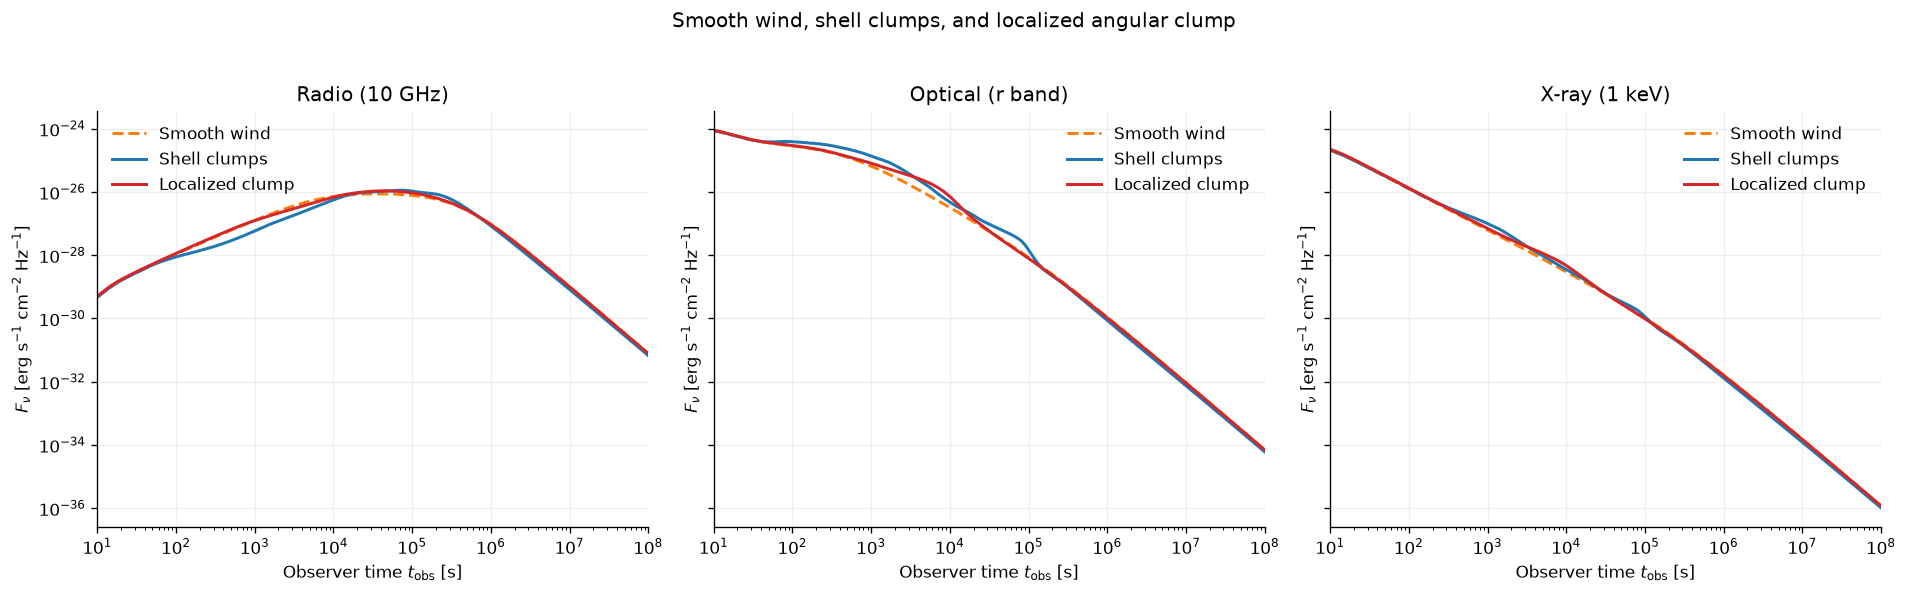

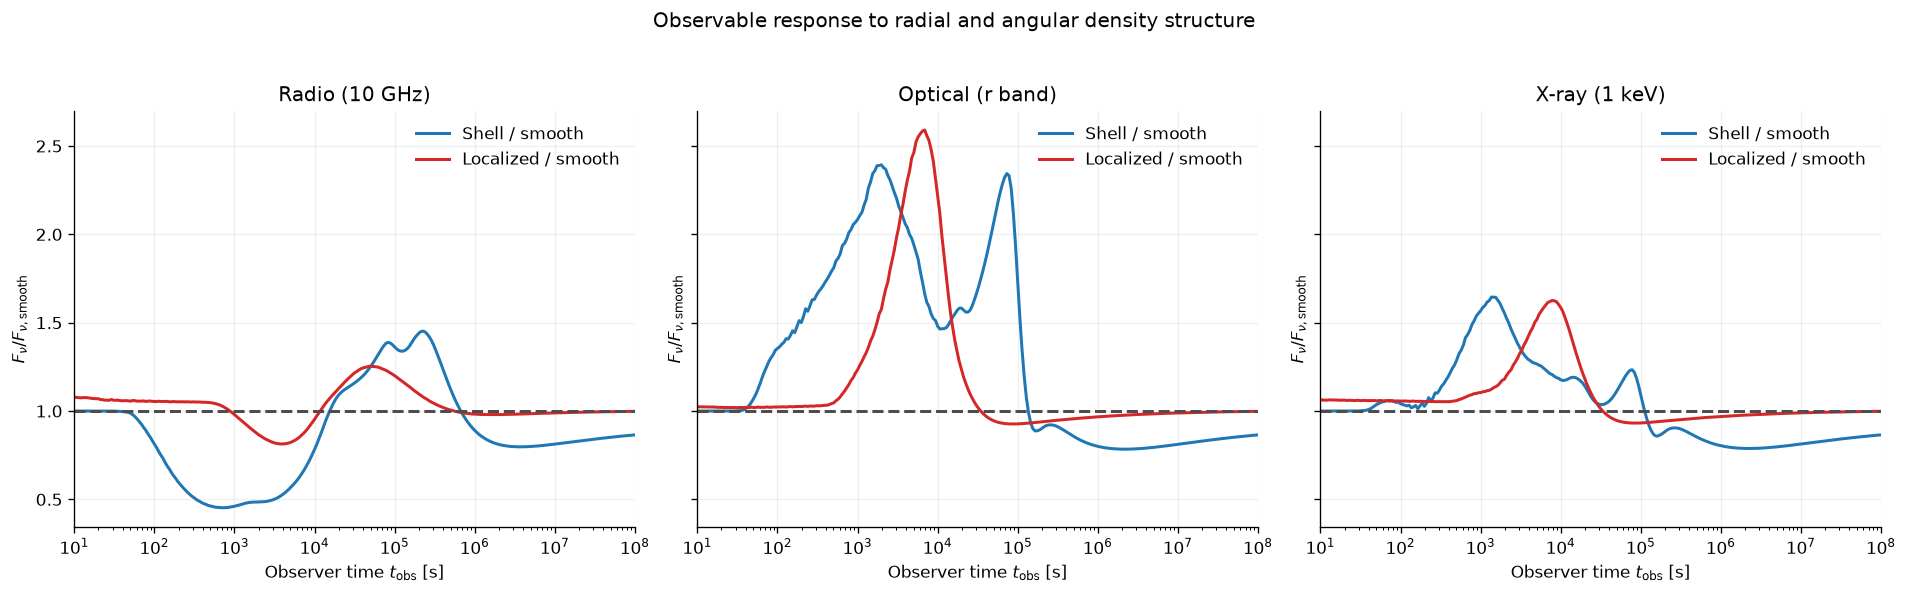

In [13]:
# ============================================================
# Smooth wind vs shell clumps vs localized angular clump
# ============================================================

smooth_wind_model = make_model(wind)
shell_clump_model = make_model(clumpy_wind)
angular_clump_model = make_model(angular_clump)

smooth_wind_lc = smooth_wind_model.flux_density_grid(
    LC_TIMES,
    band_freqs,
).total

shell_clump_lc = shell_clump_model.flux_density_grid(
    LC_TIMES,
    band_freqs,
).total

angular_clump_lc = angular_clump_model.flux_density_grid(
    LC_TIMES,
    band_freqs,
).total


# --- Light curves ---
fig, axes = plt.subplots(
    1, 3,
    figsize=TRIPLE_FIGSIZE,
    sharey=True,
)

for j, (ax, band) in enumerate(zip(axes, BANDS)):
    plot_positive(
        ax,
        LC_TIMES,
        smooth_wind_lc[j],
        color="C1",
        ls="--",
        label="Smooth wind",
    )

    plot_positive(
        ax,
        LC_TIMES,
        shell_clump_lc[j],
        color="C0",
        label="Shell clumps",
    )

    plot_positive(
        ax,
        LC_TIMES,
        angular_clump_lc[j],
        color="C3",
        label="Localized clump",
    )

    ax.set(
        xlabel=r"Observer time $t_{\rm obs}$ [s]",
        ylabel=FNU_LABEL,
        title=band,
        xlim=(LC_TIMES[0], LC_TIMES[-1]),
    )

    ax.legend()

fig.suptitle(
    "Smooth wind, shell clumps, and localized angular clump"
)

show_figure(
    fig,
    "07_shell_vs_angular_clump_light_curves",
)


# --- Ratios relative to smooth wind ---
fig, axes = plt.subplots(
    1, 3,
    figsize=TRIPLE_FIGSIZE,
    sharey=True,
)

for j, (ax, band) in enumerate(zip(axes, BANDS)):
    smooth = smooth_wind_lc[j]
    shell = shell_clump_lc[j]
    angular = angular_clump_lc[j]

    valid_shell = (
        np.isfinite(smooth)
        & np.isfinite(shell)
        & (smooth > 0)
        & (shell > 0)
    )

    valid_angular = (
        np.isfinite(smooth)
        & np.isfinite(angular)
        & (smooth > 0)
        & (angular > 0)
    )

    ax.semilogx(
        LC_TIMES[valid_shell],
        shell[valid_shell] / smooth[valid_shell],
        color="C0",
        label="Shell / smooth",
    )

    ax.semilogx(
        LC_TIMES[valid_angular],
        angular[valid_angular] / smooth[valid_angular],
        color="C3",
        label="Localized / smooth",
    )

    ax.axhline(
        1.0,
        color="0.3",
        ls="--",
    )

    ax.set(
        xlabel=r"Observer time $t_{\rm obs}$ [s]",
        ylabel=r"$F_\nu/F_{\nu,\rm smooth}$",
        title=band,
        xlim=(LC_TIMES[0], LC_TIMES[-1]),
    )

    ax.legend()

fig.suptitle(
    "Observable response to radial and angular density structure"
)

show_figure(
    fig,
    "08_shell_vs_angular_clump_ratios",
)

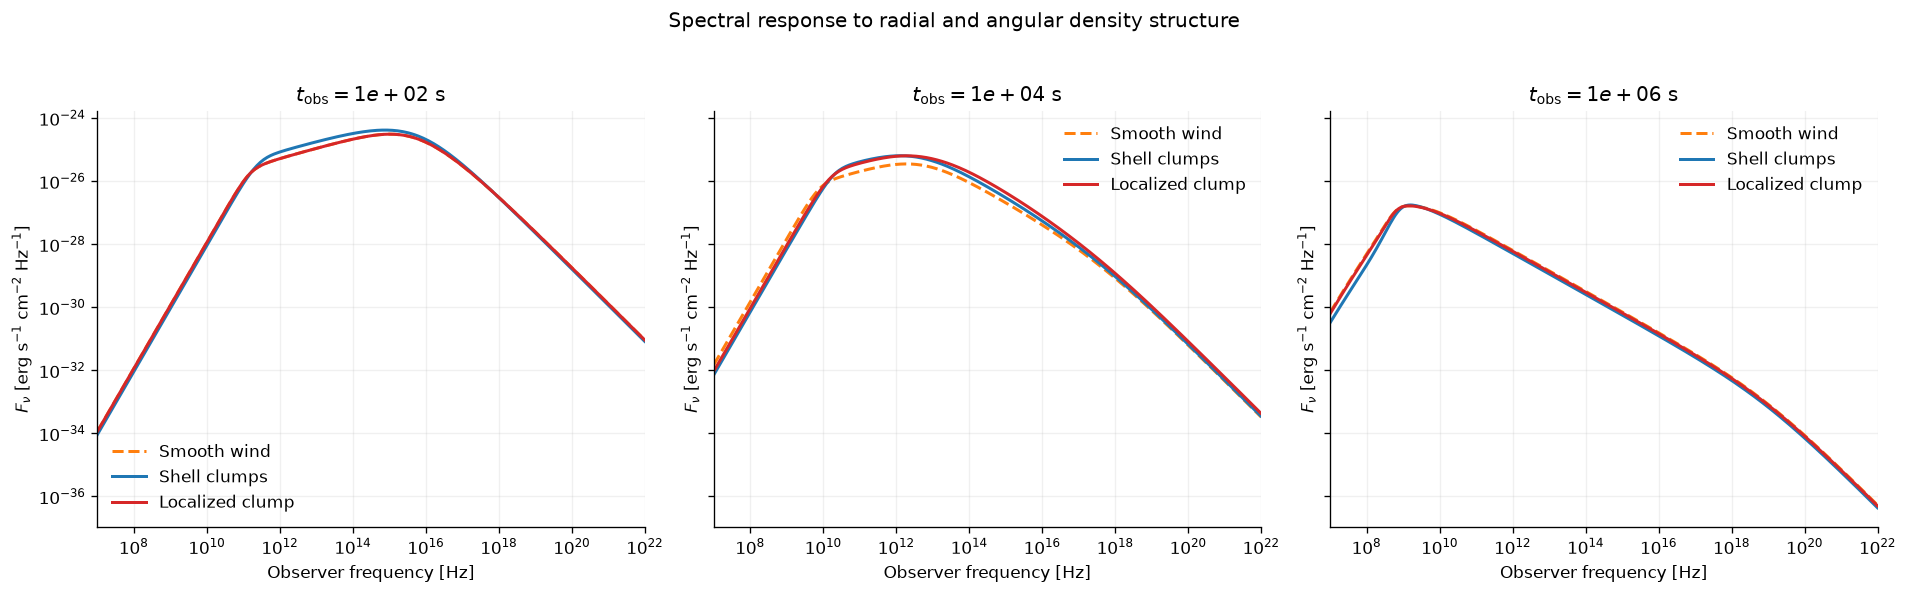

In [14]:
# ============================================================
# Spectral evolution: smooth wind vs shell clumps vs localized clump
# ============================================================

smooth_wind_spectra = smooth_wind_model.flux_density_grid(
    SPECTRUM_TIMES,
    NU,
).total

shell_clump_spectra = shell_clump_model.flux_density_grid(
    SPECTRUM_TIMES,
    NU,
).total

angular_clump_spectra = angular_clump_model.flux_density_grid(
    SPECTRUM_TIMES,
    NU,
).total


fig, axes = plt.subplots(
    1, 3,
    figsize=TRIPLE_FIGSIZE,
    sharey=True,
)

for i, (ax, t_obs) in enumerate(zip(axes, SPECTRUM_TIMES)):
    plot_positive(
        ax,
        NU,
        smooth_wind_spectra[:, i],
        color="C1",
        ls="--",
        label="Smooth wind",
    )

    plot_positive(
        ax,
        NU,
        shell_clump_spectra[:, i],
        color="C0",
        label="Shell clumps",
    )

    plot_positive(
        ax,
        NU,
        angular_clump_spectra[:, i],
        color="C3",
        label="Localized clump",
    )

    spectrum_axes(
        ax,
        rf"$t_{{\rm obs}}={t_obs:.0e}$ s",
    )

    ax.set_xlim(NU[0], NU[-1])
    ax.legend()

fig.suptitle(
    "Spectral response to radial and angular density structure"
)

show_figure(fig, "09_shell_vs_angular_clump_spectra")

## 7. Interpretation and next steps
The ISM and smooth-wind cases provide the standard limiting environments. The spherical clumpy-wind model shows how non-monotonic radial density structure modifies the afterglow without changing the synchrotron prescription, while the localized-clump model extends this to genuinely angle-dependent structure through isotropic=False.

The comparison also highlights an important observational effect: density enhancements do not map directly onto equally sharp light-curve features. The blast-wave dynamics and equal-arrival-time integration smooth the response, and a localized angular clump is additionally diluted because only part of the emitting surface encounters the overdensity. Consequently, the amplitude, duration, and timing of an observed feature depend on both the density structure and its geometry.

Useful next experiments include varying the clump radius, radial width, angular size, and density contrast; comparing isolated and multiple clumps; placing similar structure on top of a constant-density baseline; and exploring different clump locations relative to the jet axis and line of sight. For repeated fitting or large parameter scans, a native or GIL-free density callback is preferable to a plain Python function for performance.